# Drug coverage and response spread

Analysis, not pipeline. Describes the label side of the task: how many cell lines each compound was
screened against, and how much its responses vary.

| | |
|---|---|
| **reads** | `hvg5000` and `all_genes` targets h5ads — `Y_ctrp`, `M_ctrp`, `obs` |
| **writes** | `outputs/data/target_distribution.png` |

**Why coverage and spread are read together.** A compound with many measurements but no variation
across lines carries nothing to rank; one with wide variation measured on few lines carries something
that cannot be estimated. Neither number alone identifies a usable compound.

In [1]:
from pathlib import Path
import numpy as np, pandas as pd, scanpy as sc
import matplotlib.pyplot as plt

import sys
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'scripts').is_dir())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from scripts.layout import DEFAULT_CTRP_SCORE, PipelinePaths
# Derived, not hardcoded (13.08.2026, #25). Was an absolute /Users path, so the notebook ran
# on one machine only.
#
# ** THIS CHANGES WHICH FILE THE NOTEBOOK READS, and that is Selin's call, not a tidy-up. **
# The literal named ..._with_targets.h5ad -- no score suffix -- which is the PRE-11.08.2026
# artifact built on the retired `auc` target. Deriving through PipelinePaths necessarily
# resolves to the current DEFAULT_CTRP_SCORE ('auc_cc'). The score is spelled out below
# rather than left implicit, so which target this notebook reads is visible in the cell
# instead of hidden in a default. Neither file exists on disk yet (nothing has been re-run).
SCORE = DEFAULT_CTRP_SCORE
TARGETS = PipelinePaths.build(None, 'hvg5000', SCORE).targets_h5ad
print(f'target artifact: {TARGETS.name}')
a = sc.read_h5ad(TARGETS, backed='r')
drugs = list(a.uns['ctrp_drugs'])
print(f'{len(drugs)} drugs, {a.n_obs} cells')

target artifact: SCP542_CCLE_scGPT_human_embeddings_with_targets_auc_cc.h5ad


534 drugs, 53513 cells


## 1 · Collapse to one row per cell line

| | |
|---|---|
| **out** | the (cell line × drug) label matrix, without the per-cell duplication |

The label is defined per (cell line, drug) and broadcast to every cell of that line, so any per-drug
statistic must be taken per line — otherwise a 1,990-cell line counts 35 times a 56-cell one for the
same single measurement.

In [2]:
cl = a.obs['Cell_line'].astype(str).values
M = np.asarray(a.obsm['M_ctrp']).astype(bool)          # observed mask (n_cells, 545)
Y = np.asarray(a.obsm['Y_ctrp'], dtype=float)          # viability, NaN/0 where missing

rep = pd.DataFrame({'cl': cl}).drop_duplicates('cl')   # first cell per line, preserves order
line_names = rep['cl'].values
rows = rep.index.values
M_line = M[rows]                                       # (n_lines, 545)
Y_line = np.where(M_line, Y[rows], np.nan)             # mask-truth: NaN where not screened

n_lines = len(line_names)
lines_with_any = int(M_line.any(1).sum())
print(f'{n_lines} unique SCP542 cell lines; {lines_with_any} overlap CTRPv2 (have >=1 drug label)')

198 unique SCP542 cell lines; 181 overlap CTRPv2 (have >=1 drug label)


## 2 · Per-drug coverage

| | |
|---|---|
| **out** | for each compound, how many of the overlapping cell lines were screened against it |

In [3]:
cov = M_line.sum(0)                                     # lines per drug
resp_std = np.nanstd(Y_line, axis=0)                   # response spread across lines
resp_mean = np.nanmean(Y_line, axis=0)
drug_df = pd.DataFrame({
    'drug': drugs,
    'n_lines': cov,
    'pct_of_overlap': 100 * cov / lines_with_any,
    'resp_mean': resp_mean,
    'resp_std': resp_std,
}).sort_values('n_lines', ascending=False).reset_index(drop=True)

print('coverage summary (lines per drug):')
print(drug_df['n_lines'].describe()[['min','25%','50%','75%','max']].round(1).to_string())
print(f"\ndrugs measured on ALL {lines_with_any} overlapping lines: "
      f"{(cov == lines_with_any).sum()} / {len(drugs)}")
print(f"drugs measured on >=90% of overlapping lines: {(drug_df['pct_of_overlap']>=90).sum()}")
print(f"drugs measured on <50% of overlapping lines:  {(drug_df['pct_of_overlap']<50).sum()}")

coverage summary (lines per drug):
min     51.0
25%    158.2
50%    174.0
75%    176.0
max    180.0

drugs measured on ALL 181 overlapping lines: 0 / 534
drugs measured on >=90% of overlapping lines: 390
drugs measured on <50% of overlapping lines:  67


## 3 · Coverage against response variance

| | |
|---|---|
| **out** | the two quantities on one axis, per compound |

They are independent: being widely screened says nothing about whether the responses differ between
lines. The plot exists so that neither is read as a proxy for the other.

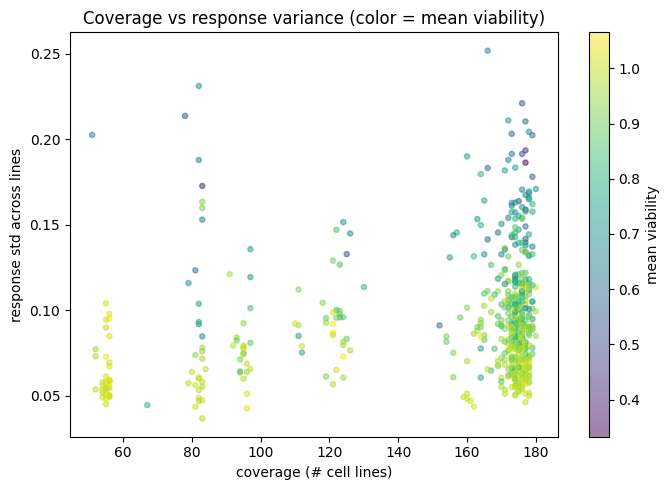

low-variance drugs (std < 0.05) — little to learn even if well covered: 18


In [4]:
fig, ax = plt.subplots(figsize=(7, 5))
sc_ = ax.scatter(drug_df['n_lines'], drug_df['resp_std'], s=14, alpha=0.5, c=drug_df['resp_mean'], cmap='viridis')
ax.set_xlabel('coverage (# cell lines)'); ax.set_ylabel('response std across lines')
ax.set_title('Coverage vs response variance (color = mean viability)')
fig.colorbar(sc_, label='mean viability'); plt.tight_layout(); plt.show()
print('low-variance drugs (std < 0.05) — little to learn even if well covered:',
      int((drug_df['resp_std'] < 0.05).sum()))

## 4 · Target distribution

| | |
|---|---|
| **out** | `outputs/data/target_distribution.png` — four panels on the raw response values |

Why the task is hard, in the labels alone and with no model involved. The responses are concentrated
in a narrow band with the pharmacologically interesting extremes sparse — so an unweighted squared
error is dominated by the crowded middle, and the optimum shrinks toward each compound's mean.

That is the observation the density weighting in `4a` responds to, and it is shown here on the data
rather than inferred from a training curve.

observed (line x drug) values: 81906
  median viability 0.925; frac>=0.8 0.77; frac>=0.9 0.57
per-drug std median 0.089; frac flat (<0.05) 0.03
loose filter keeps 438/534 (cov>=100 & std>=0.05)


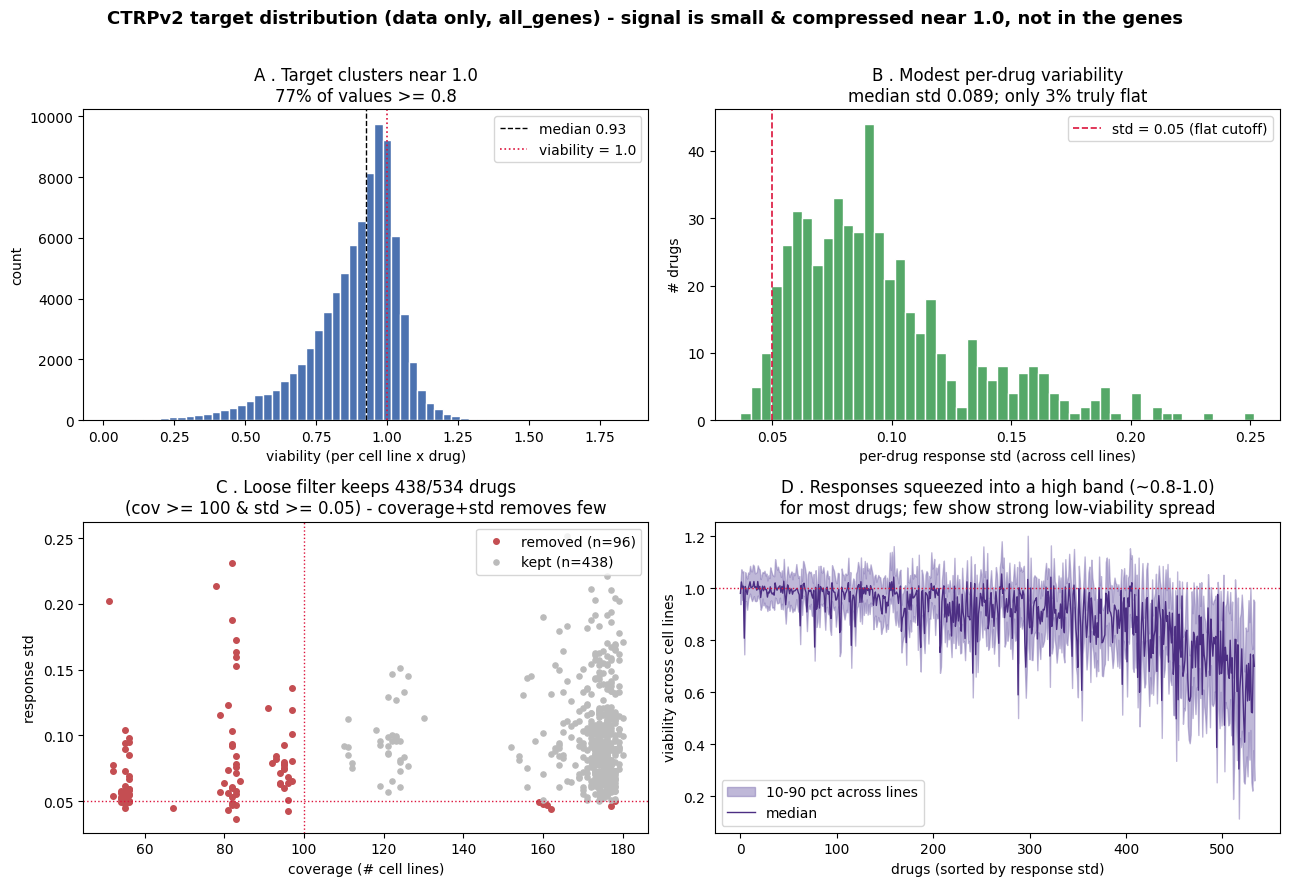

In [5]:
import sys
from pathlib import Path
import numpy as np
import scanpy as sc
import matplotlib.pyplot as plt

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'scripts').is_dir())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from scripts.layout import PipelinePaths

# Named for the subdirectory it writes to, not the flat root (audit #24, 13.08.2026):
# a new write against a bare OUT would land in outputs/ itself. Resolved path unchanged.
OUT_DATA = ROOT / 'notebooks' / 'outputs' / 'data'; OUT_DATA.mkdir(parents=True, exist_ok=True)

# Target is gene-set-independent; read all_genes in backed mode (big .X stays on disk).
ad = sc.read_h5ad(PipelinePaths.build(None, 'all_genes').targets_h5ad, backed='r')
lines = ad.obs['Cell_line'].astype(str).to_numpy()
Y = np.asarray(ad.obsm['Y_ctrp'], dtype=float)
M = np.asarray(ad.obsm['M_ctrp'], dtype=bool)
drugs = list(ad.uns['ctrp_drugs']); K = len(drugs)
uniq = np.unique(lines)

# Collapse to the real (cell line x drug) measurements. The bulk label is constant
# within a line (broadcast to its cells) -> per-line value = mean over observed cells.
V = np.full((len(uniq), K), np.nan)
for i, ln in enumerate(uniq):
    idx = np.flatnonzero(lines == ln); m = M[idx]
    has = m.any(0); cnt = m.sum(0); s = np.where(m, Y[idx], 0.0).sum(0)
    V[i, has] = s[has] / cnt[has]

obs_vals = V[np.isfinite(V)]
cov = np.isfinite(V).sum(0); std = np.nanstd(V, 0); fs = np.isfinite(std)
COV_MIN, STD_MIN = 100, 0.05
keep = (cov >= COV_MIN) & (std >= STD_MIN)
print(f"observed (line x drug) values: {obs_vals.size}")
print(f"  median viability {np.median(obs_vals):.3f}; frac>=0.8 {(obs_vals>=0.8).mean():.2f}; frac>=0.9 {(obs_vals>=0.9).mean():.2f}")
print(f"per-drug std median {np.nanmedian(std):.3f}; frac flat (<{STD_MIN}) {(std[fs]<STD_MIN).mean():.2f}")
print(f"loose filter keeps {int(keep.sum())}/{K} (cov>={COV_MIN} & std>={STD_MIN})")

fig, ax = plt.subplots(2, 2, figsize=(13, 9))

a = ax[0, 0]
a.hist(obs_vals, bins=60, color="#4C72B0", edgecolor="white")
a.axvline(np.median(obs_vals), color="k", ls="--", lw=1, label=f"median {np.median(obs_vals):.2f}")
a.axvline(1.0, color="crimson", ls=":", lw=1.2, label="viability = 1.0")
a.set_xlabel("viability (per cell line x drug)"); a.set_ylabel("count")
a.set_title(f"A . Target clusters near 1.0\n{(obs_vals>=0.8).mean()*100:.0f}% of values >= 0.8"); a.legend()

b = ax[0, 1]
b.hist(std[fs], bins=50, color="#55A868", edgecolor="white")
b.axvline(STD_MIN, color="crimson", ls="--", lw=1.2, label=f"std = {STD_MIN} (flat cutoff)")
b.set_xlabel("per-drug response std (across cell lines)"); b.set_ylabel("# drugs")
b.set_title(f"B . Modest per-drug variability\nmedian std {np.nanmedian(std):.3f}; only {(std[fs]<STD_MIN).mean()*100:.0f}% truly flat"); b.legend()

c = ax[1, 0]
c.scatter(cov[~keep], std[~keep], s=16, c="#C44E52", label=f"removed (n={int((~keep).sum())})")
c.scatter(cov[keep], std[keep], s=14, c="#bbbbbb", label=f"kept (n={int(keep.sum())})")
c.axhline(STD_MIN, color="crimson", ls=":", lw=1); c.axvline(COV_MIN, color="crimson", ls=":", lw=1)
c.set_xlabel("coverage (# cell lines)"); c.set_ylabel("response std")
c.set_title(f"C . Loose filter keeps {int(keep.sum())}/{K} drugs\n(cov >= {COV_MIN} & std >= {STD_MIN}) - coverage+std removes few"); c.legend()

d = ax[1, 1]
order = np.argsort(np.where(fs, std, -1)); xs = np.arange(K)
lo = np.nanpercentile(V, 10, axis=0)[order]; hi = np.nanpercentile(V, 90, axis=0)[order]
md = np.nanmedian(V, axis=0)[order]
d.fill_between(xs, lo, hi, color="#8172B3", alpha=0.5, label="10-90 pct across lines")
d.plot(xs, md, color="#4C2E83", lw=1, label="median"); d.axhline(1.0, color="crimson", ls=":", lw=1)
d.set_xlabel("drugs (sorted by response std)"); d.set_ylabel("viability across cell lines")
d.set_title("D . Responses squeezed into a high band (~0.8-1.0)\nfor most drugs; few show strong low-viability spread"); d.legend(loc="lower left")

fig.suptitle("CTRPv2 target distribution (data only, all_genes) - signal is small & compressed near 1.0, not in the genes",
             fontsize=13, fontweight="bold")
fig.tight_layout(rect=[0, 0, 1, 0.97])
fig.savefig(OUT_DATA / "target_distribution.png", dpi=150); plt.show()